In [1]:
import pandas as pd
import numpy as np
import os

In [343]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, recall_score, accuracy_score, precision_score, f1_score,classification_report,confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, auc


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
os.getcwd()

'/home/euphrates/Desktop/dreps/DS/Radiomics/Boun-radiomics/notebooks/ozyegin'

In [5]:
os.listdir("CSV")

['rcc2.csv',
 'rcc1.csv',
 'originalitself.csv',
 'flippedOriginal.csv',
 'dilatedResized.csv',
 'erodedOriginal.csv',
 'dilatedOriginal.csv',
 'resizeditself.csv',
 'erodedResized.csv',
 'flippedResized.csv']

###  UCSF  --arterial  -- aml

In [265]:
reg = pd.read_csv('CSV/phase_reg_key.csv')

In [408]:
reg.columns

Index(['pid', 'noncon', 'arterial', 'delay', 'portven', 'mask',
       'ct_manufacturer', 'patient_age_years', 'patient_sex', 'pathology',
       'tumor_type', 'pathology_grade', 'tumor_laterality', 'tumor_size_cm',
       'tumor_biopsy_type'],
      dtype='object')

In [412]:
reg[(reg['tumor_type'].isin(['angiomyolipoma']))or(reg['pathology'].isin(['angiomyolipoma']))]

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [418]:
reg[reg['tumor_type'].isin(['angiomyolipoma'])][["pid",'tumor_type','pathology']]

,pid,tumor_type,pathology
0,08FBroxzI6,angiomyolipoma,angiomyolipoma
16,1FeC2cgqyj,angiomyolipoma,angiomyolipoma
21,1a7jTnjpn9,angiomyolipoma,angiomyolipoma
35,34jxhEPOGB,angiomyolipoma,angiomyolipoma
45,45Nh52EJwK,angiomyolipoma,angiomyolipoma
108,9Aue4ckfn8,angiomyolipoma,angiomyolipoma
123,AHXeVFmpFK,angiomyolipoma,angiomyolipoma
167,Cwg6Hv9E0n,angiomyolipoma,angiomyolipoma
178,Di7ARaJ8S6,angiomyolipoma,angiomyolipoma
239,IIFf4GZnYx,angiomyolipoma,angiomyolipoma


In [419]:
reg[reg['tumor_type'].isin(['angiomyolipoma'])][["pid",'tumor_type','pathology']].shape

(30, 3)

In [421]:
os.listdir("/media/euphrates/DS-Backup/angiomyolipoma/ucsf-rmac-dataset")

['1a7jTnjpn9.hdf5',
 'oo2Q4ig2bL.hdf5',
 '1FeC2cgqyj.hdf5',
 'AHXeVFmpFK.hdf5',
 'Cwg6Hv9E0n.hdf5',
 'cwHnolRFQo.hdf5',
 'Di7ARaJ8S6.hdf5',
 'dkp1S2CrhL.hdf5',
 'flGZ1oVmQ3.hdf5',
 'fsbMU5j9mQ.hdf5',
 'gsresoXGbA.hdf5',
 'IIFf4GZnYx.hdf5',
 'JMfIEEWlAz.hdf5',
 'lyWL7zzWWi.hdf5',
 'pXwitKy0oU.hdf5',
 'STimK6AjK1.hdf5',
 'tJYRUhVuhr.hdf5',
 'TUwzGuHPtD.hdf5',
 'VQwDzzw84L.hdf5',
 'WooVhg7ysO.hdf5',
 'WRfSZV3lw8.hdf5',
 'WxXHUmns4v.hdf5',
 '08FBroxzI6.hdf5',
 '9Aue4ckfn8.hdf5',
 '34jxhEPOGB.hdf5',
 '45Nh52EJwK.hdf5',
 'nSIvfJZBlK.hdf5',
 'NskoBo0acF.hdf5',
 'Q5hPqtDCir.hdf5',
 'qhveYUigqX.hdf5']

In [426]:
[i for i in reg[reg['pathology'].isin(['angiomyolipoma'])].pid if i not in [i.split('.')[0] for i in os.listdir("/media/euphrates/DS-Backup/angiomyolipoma/ucsf-rmac-dataset")]]

[]

In [425]:
[i.split('.')[0] for i in os.listdir("/media/euphrates/DS-Backup/angiomyolipoma/ucsf-rmac-dataset")]

['1a7jTnjpn9',
 'oo2Q4ig2bL',
 '1FeC2cgqyj',
 'AHXeVFmpFK',
 'Cwg6Hv9E0n',
 'cwHnolRFQo',
 'Di7ARaJ8S6',
 'dkp1S2CrhL',
 'flGZ1oVmQ3',
 'fsbMU5j9mQ',
 'gsresoXGbA',
 'IIFf4GZnYx',
 'JMfIEEWlAz',
 'lyWL7zzWWi',
 'pXwitKy0oU',
 'STimK6AjK1',
 'tJYRUhVuhr',
 'TUwzGuHPtD',
 'VQwDzzw84L',
 'WooVhg7ysO',
 'WRfSZV3lw8',
 'WxXHUmns4v',
 '08FBroxzI6',
 '9Aue4ckfn8',
 '34jxhEPOGB',
 '45Nh52EJwK',
 'nSIvfJZBlK',
 'NskoBo0acF',
 'Q5hPqtDCir',
 'qhveYUigqX']

In [427]:
'dkp1S2CrhL' in [i.split('.')[0] for i in os.listdir("/media/euphrates/DS-Backup/angiomyolipoma/ucsf-rmac-dataset")]

True

In [266]:
dd1= pd.read_csv('CSV/dilatedOriginal.csv')

In [267]:
dd1.shape

(8, 1180)

In [268]:
dd1['augmentation'] = 'dilated'
dd1['source_subset'] = 'Original'


In [269]:
dd2= pd.read_csv('CSV/dilatedResized.csv')

In [270]:
dd2.shape

(3, 1180)

In [271]:
dd2['augmentation'] = 'dilated'
dd2['source_subset'] = 'Resized'

In [272]:
df1= pd.read_csv('CSV/flippedOriginal.csv')

In [273]:
df1.shape

(8, 1180)

In [274]:
df1['augmentation'] = 'flipped'
df1['source_subset'] = 'Original'

In [275]:
df2 = pd.read_csv('CSV/flippedResized.csv')

In [276]:
df2.shape

(3, 1180)

In [277]:
df2['augmentation'] = 'flipped'
df2['source_subset'] = 'Resized'

In [278]:
de1 = pd.read_csv('CSV/erodedOriginal.csv')

In [279]:
de1.shape

(8, 1180)

In [280]:
de1['augmentation'] = 'eroded'
de1['source_subset'] = 'Original'

In [281]:
de2 = pd.read_csv('CSV/erodedResized.csv')

In [282]:
de2.shape

(3, 1180)

In [283]:
de2['augmentation'] = 'eroded'
de2['source_subset'] = 'Resized'

In [284]:
do = pd.read_csv('CSV/originalitself.csv')

In [285]:
do.shape

(8, 1180)

In [286]:
do['augmentation'] = 'NOT'
do['source_subset'] = 'Original'

In [287]:
dr = pd.read_csv('CSV/resizeditself.csv')

In [288]:
dr.shape

(3, 1180)

In [289]:
dr['augmentation'] = 'NOT'
dr['source_subset'] = 'Resized'

In [290]:
drcc1 = pd.read_csv('CSV/rcc1.csv')
drcc1.shape

(23, 1180)

In [291]:
drcc1['augmentation'] = 'NOT'
drcc1['source_subset'] = 'Original-RCC'

In [292]:
drcc2 = pd.read_csv('CSV/rcc2.csv')

In [293]:
drcc2.shape

(35, 1180)

In [294]:
drcc2['augmentation'] = 'NOT'
drcc2['source_subset'] = 'Original-RCC'

In [295]:
dfA= pd.concat([dd1,dd2,df1,df2,de1,de2,do,dr], axis = 0, ignore_index= 1)

In [296]:
dfA.shape

(44, 1182)

In [297]:
dfA['target'] = 1

In [298]:
dfR = pd.concat([drcc1,drcc2], axis = 0, ignore_index= 1)

In [299]:
dfR.shape

(58, 1182)

In [300]:
dfR['target'] = 0

In [301]:
dfU = pd.concat([dfA,dfR], axis = 0, ignore_index= 1)

In [302]:
dfU.drop('pathology_grade', axis =1, inplace= True)

In [303]:
dfU['case_id'] = dfU.PID

In [304]:
y = dfU['target']

In [305]:
df_backup = dfU[['case_id','augmentation','source_subset','target']]

In [306]:
df_backup.sample(10)

,case_id,augmentation,source_subset,target
71,B3uXUCxmk3,NOT,Original-RCC,0
63,aiMWXsF8Vr,NOT,Original-RCC,0
69,5VcthT0eZp,NOT,Original-RCC,0
31,NskoBo0acF,eroded,Resized,1
58,QPHEXsfL0J,NOT,Original-RCC,0
9,NskoBo0acF,dilated,Resized,1
28,qhveYUigqX,eroded,Original,1
4,WooVhg7ysO,dilated,Original,1
67,475HQrHo5Y,NOT,Original-RCC,0
62,XMMDMynVEF,NOT,Original-RCC,0


In [307]:
dfU.isnull().sum()

PID                                      0
label                                    0
tumor_type                               0
pathology                                0
Patient_Age                              0
                                        ..
diagnostics_Mask-interpolated_Maximum    0
augmentation                             0
source_subset                            0
target                                   0
case_id                                  0
Length: 1183, dtype: int64

In [48]:
dfU.select_dtypes(include='object').groupby('Manufacturer')['Manufacturer'].count()

Manufacturer
GE MEDICAL SYSTEMS BrightSpeed            1
GE MEDICAL SYSTEMS Discovery CT750 HD    10
GE MEDICAL SYSTEMS Discovery STE          1
GE MEDICAL SYSTEMS GENESIS_ZEUS           1
GE MEDICAL SYSTEMS HiSpeed CT/i           4
GE MEDICAL SYSTEMS LightSpeed Pro 16      1
GE MEDICAL SYSTEMS LightSpeed QX/i        1
GE MEDICAL SYSTEMS LightSpeed Ultra       4
GE MEDICAL SYSTEMS LightSpeed VCT        23
GE MEDICAL SYSTEMS LightSpeed16           8
GE MEDICAL SYSTEMS Optima CT660           7
GE MEDICAL SYSTEMS Revolution CT          1
Philips Brilliance 64                     2
Philips Ingenuity CT                      1
Philips Mx8000 IDT                        1
Philips Mx8000 IDT 16                     7
SIEMENS Biograph 64                       1
SIEMENS SOMATOM Definition AS             2
SIEMENS SOMATOM Definition AS+            3
SIEMENS SOMATOM Definition Flash          1
SIEMENS Sensation 16                      2
SIEMENS Sensation 40                      4
SIEMENS Sensation 6

(array([-200.,    0.,  200.,  400.,  600.,  800., 1000., 1200., 1400.]),
 [Text(-200.0, 0, 'wavelet-HHL_ngtdm_Strength'),
  Text(0.0, 0, 'tumor_type'),
  Text(200.0, 0, 'log-sigma-1-0-mm-3D_ngtdm_Contrast'),
  Text(400.0, 0, 'wavelet-LLH_firstorder_RobustMeanAbsoluteDeviation'),
  Text(600.0, 0, 'wavelet-LHH_glcm_DifferenceVariance'),
  Text(800.0, 0, 'wavelet-HLH_glcm_SumEntropy'),
  Text(1000.0, 0, 'wavelet-HHH_glrlm_RunVariance'),
  Text(1200.0, 0, ''),
  Text(1400.0, 0, '')])

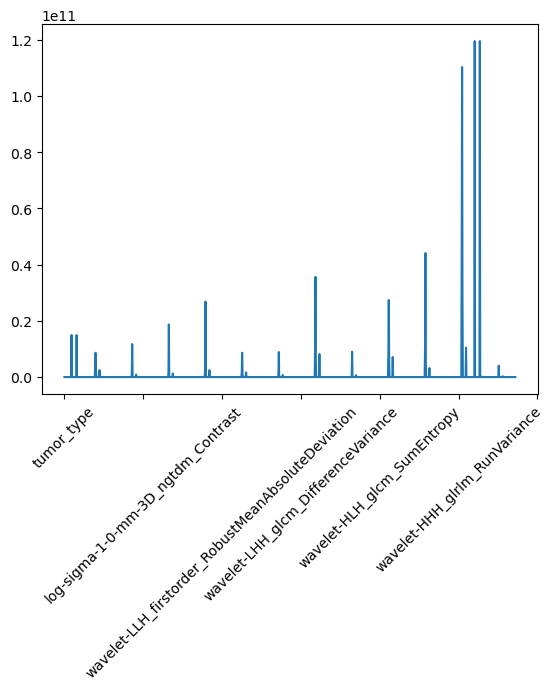

In [58]:
dfU.groupby('Manufacturer')[dfU.select_dtypes(exclude='object').columns].mean().sum().plot.line()
plt.xticks(rotation = 45)

In [377]:

from sklearn.decomposition import PCA

In [378]:
dfU.select_dtypes(exclude = "object").shape

(102, 1146)

In [379]:
dfU.drop(columns=['case_id','augmentation','source_subset','target'],axis=1).select_dtypes(exclude = "object").shape

(102, 1145)

In [380]:
df_pca = dfU.drop(['case_id','augmentation','source_subset','target'],axis=1).select_dtypes(exclude = "object")

In [381]:
sc = StandardScaler()

In [382]:
scaled_df_pca = sc.fit_transform(df_pca)

In [383]:
pc = PCA().fit(scaled_df_pca)

In [384]:
len(pc.explained_variance_ratio_)

102

Text(0, 0.5, 'Variance Ratio')

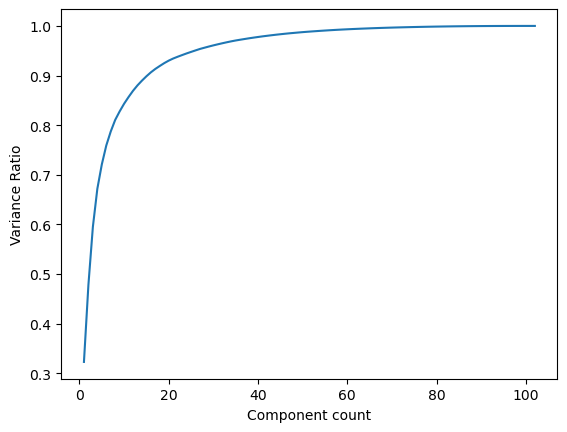

In [385]:
x = range(1,103)
plt.plot(x, np.cumsum(pc.explained_variance_ratio_),)
plt.xlabel("Component count")
plt.ylabel("Variance Ratio")

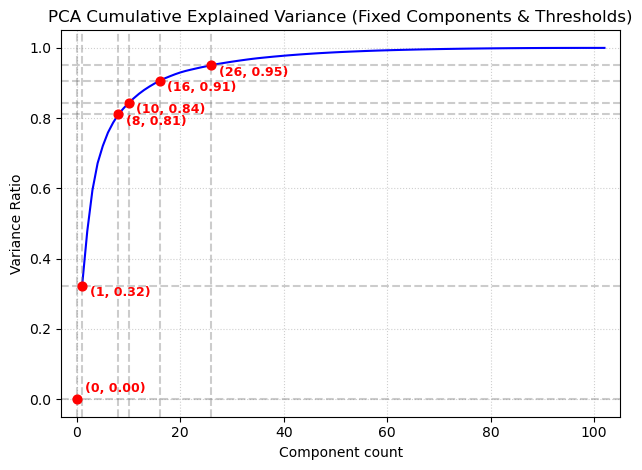

In [386]:
import numpy as np
import matplotlib.pyplot as plt

# Your original setup
x = range(1, 103)
cum_sum = np.cumsum(pc.explained_variance_ratio_)

# Create the base plot
plt.plot(x, cum_sum, color='blue', label='Cumulative Variance')
plt.xlabel("Component count")
plt.ylabel("Variance Ratio")

# Keep a set of coordinates to avoid duplicate labels if thresholds and components overlap
processed_points = set()

# --- 1. Process specific component counts ---
target_components = [0, 1, 10]

for c in target_components:
    if c == 0:
        comp_count, actual_val = 0, 0.0
    elif c in x:
        idx = list(x).index(c)
        comp_count, actual_val = c, cum_sum[idx]
    else:
        continue
    processed_points.add((comp_count, actual_val))

# --- 2. Process threshold variables from the former code ---
thresholds = [0.80, 0.90, 0.95]

for t in thresholds:
    under_threshold_indices = np.where(cum_sum >= t)[0]
    if len(under_threshold_indices) > 0:
        idx = under_threshold_indices[0]
        comp_count, actual_val = x[idx], cum_sum[idx]
        processed_points.add((comp_count, actual_val))

# --- 3. Plot and Annotate all unique critical points ---
for comp_count, actual_val in sorted(processed_points):
    # Plot a red dot on the critical point
    plt.scatter(comp_count, actual_val, color='red', s=40, zorder=5)
    
    # Draw dashed guide lines to the axes
    plt.axvline(x=comp_count, color='gray', linestyle='--', alpha=0.4)
    plt.axhline(y=actual_val, color='gray', linestyle='--', alpha=0.4)
    
    # Dynamic text positioning: if it's near (0,0), push text up. Otherwise, push it down.
    y_offset = 0.02 if actual_val < 0.1 else -0.03
    
    # Display the exact axis numbers next to the point
    plt.text(comp_count + 1.5, actual_val + y_offset, f"({comp_count}, {actual_val:.2f})", 
             fontsize=9, color='red', weight='bold')

plt.title("PCA Cumulative Explained Variance (Fixed Components & Thresholds)")
plt.grid(True, linestyle=':', alpha=0.6)

# Provide some breathing room on the canvas edges for the labels
plt.xlim(-3, 105)
plt.ylim(-0.05, 1.05)

plt.tight_layout()

# Save or display the plot
plt.savefig("explained_variance_plot.png")

In [387]:
scaled_df_pca.shape

(102, 1145)

In [388]:
pca = PCA(n_components=26)

In [389]:
p_scaled = pca.fit_transform(scaled_df_pca)

In [390]:
X = p_scaled

In [391]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.1, random_state= 43 )

In [392]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    
    print("Test_Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    print("Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

### SVM

In [393]:
from sklearn.svm import SVC
svc = SVC(kernel='rbf')

In [394]:
svc.fit(X_train,y_train)

SVC()

In [395]:
y_pred = svc.predict(X_test)

In [396]:
y_pred

array([1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1])

In [397]:
y_test

20    1
2     1
15    1
22    1
57    0
93    0
69    0
55    0
11    1
80    0
9     1
Name: target, dtype: int64

In [398]:
eval_metric(svc, X_train, y_train, X_test, y_test)

Test_Set
[[4 1]
 [2 4]]
              precision    recall  f1-score   support

           0       0.67      0.80      0.73         5
           1       0.80      0.67      0.73         6

    accuracy                           0.73        11
   macro avg       0.73      0.73      0.73        11
weighted avg       0.74      0.73      0.73        11


Train_Set
[[53  0]
 [ 5 33]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        53
           1       1.00      0.87      0.93        38

    accuracy                           0.95        91
   macro avg       0.96      0.93      0.94        91
weighted avg       0.95      0.95      0.94        91



In [404]:
from sklearn.metrics import RocCurveDisplay,PrecisionRecallDisplay,ConfusionMatrixDisplay

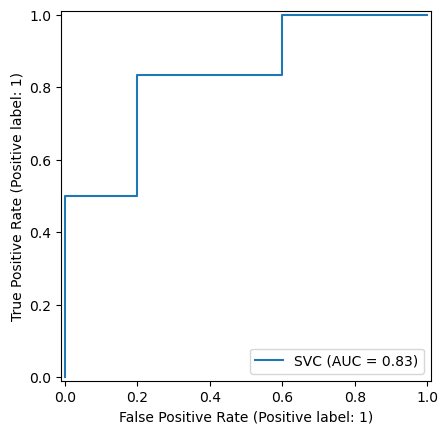

In [402]:
RocCurveDisplay.from_estimator(svc,X_test,y_test)
plt.show()

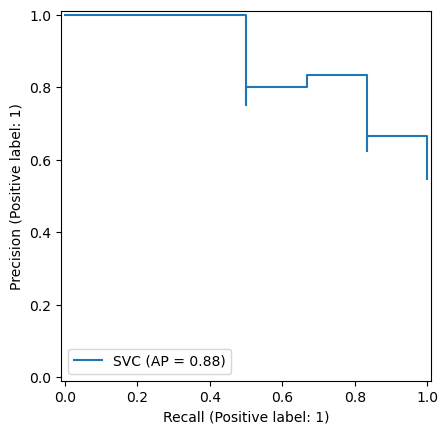

In [407]:
PrecisionRecallDisplay.from_estimator(svc,X_test,y_test)
plt.show()

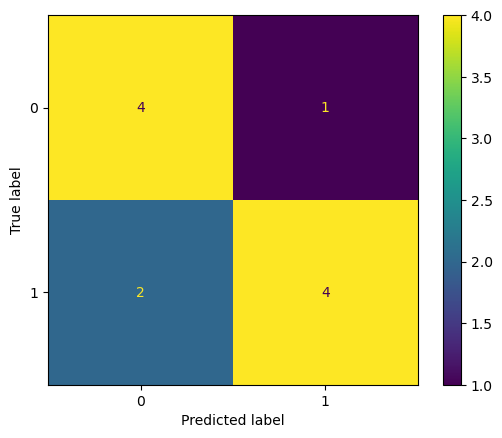

In [405]:
ConfusionMatrixDisplay.from_estimator(svc,X_test,y_test)
plt.show()

### XGBoost

In [337]:
from xgboost import XGBClassifier
xg = XGBClassifier()

In [338]:
xg.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [339]:
y_pred = xg.predict(X_test)

In [341]:
eval_metric(xg,X_train,y_train,X_test,y_test)

Test_Set
[[4 1]
 [3 3]]
              precision    recall  f1-score   support

           0       0.57      0.80      0.67         5
           1       0.75      0.50      0.60         6

    accuracy                           0.64        11
   macro avg       0.66      0.65      0.63        11
weighted avg       0.67      0.64      0.63        11


Train_Set
[[53  0]
 [ 0 38]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        38

    accuracy                           1.00        91
   macro avg       1.00      1.00      1.00        91
weighted avg       1.00      1.00      1.00        91



In [405]:
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns
import matplotlib.pyplot as plt 


In [ ]:
cm = confusion_matrix(y_test,y_pred)

In [ ]:
cm

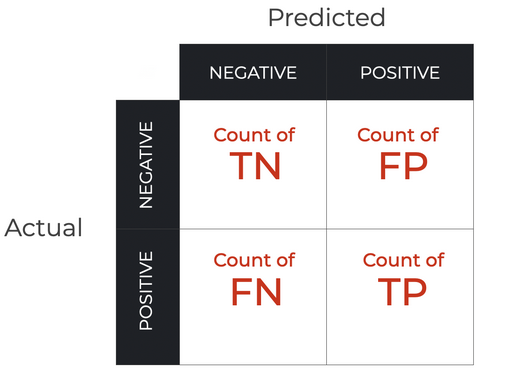

### Logistic Regression

In [344]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()

In [345]:
classifier.fit(X_train,y_train)

LogisticRegression()

In [347]:
y_pred = classifier.predict(X_test)

In [348]:

eval_metric(classifier, X_train, y_train, X_test, y_test)

Test_Set
[[2 3]
 [1 5]]
              precision    recall  f1-score   support

           0       0.67      0.40      0.50         5
           1       0.62      0.83      0.71         6

    accuracy                           0.64        11
   macro avg       0.65      0.62      0.61        11
weighted avg       0.64      0.64      0.62        11


Train_Set
[[51  2]
 [ 1 37]]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        53
           1       0.95      0.97      0.96        38

    accuracy                           0.97        91
   macro avg       0.96      0.97      0.97        91
weighted avg       0.97      0.97      0.97        91



In [370]:
pol_feature = PolynomialFeatures(degree=2)
X_train = pol_feature.fit_transform(X_train)

In [371]:
X_train.shape

(91, 378)

In [372]:
X_test = pol_feature.transform(X_test)

In [373]:
classifier.fit(X_train,y_train)

LogisticRegression()

In [374]:
y_pred = classifier.predict(X_test)

In [375]:

eval_metric(classifier, X_train, y_train, X_test, y_test)

Test_Set
[[4 1]
 [3 3]]
              precision    recall  f1-score   support

           0       0.57      0.80      0.67         5
           1       0.75      0.50      0.60         6

    accuracy                           0.64        11
   macro avg       0.66      0.65      0.63        11
weighted avg       0.67      0.64      0.63        11


Train_Set
[[53  0]
 [ 0 38]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        38

    accuracy                           1.00        91
   macro avg       1.00      1.00      1.00        91
weighted avg       1.00      1.00      1.00        91

